# ⬡ Nexus Draw — CNN Training

This notebook trains a convolutional neural network to classify hand-drawn sketches into **25 categories**, using Google's [Quick, Draw!](https://quickdraw.withgoogle.com/data) dataset. The trained model is exported to TensorFlow.js so it can run directly in the browser.

**Pipeline**

1. Install dependencies and set configuration
2. Download and preview the Quick Draw dataset
3. Build a preprocessed train / validation split
4. Apply data augmentation
5. Train a CNN with batch normalization, dropout, and cosine learning-rate decay
6. Evaluate accuracy and inspect predictions
7. Export the trained model to TensorFlow.js

**Target validation accuracy:** 95%+

**Categories (25):** airplane · apple · bicycle · bird · book · butterfly · car · cat · circle · clock · cloud · dog · fish · flower · guitar · house · moon · pizza · shoe · square · star · sun · tree · triangle · umbrella

> Run all cells in order, top to bottom. The first run downloads roughly 30–80 MB per category and caches the files locally, so later runs skip straight to loading from cache.

## 1 · Setup

Install the packages this notebook needs.

In [19]:
import subprocess, sys

packages = ['tensorflow', 'numpy', 'matplotlib', 'scikit-learn', 'requests', 'tqdm']
subprocess.run([sys.executable, '-m', 'pip', 'install', *packages], check=True)
print('All packages ready ✓')

All packages ready ✓


## 2 · Imports & Configuration

Import libraries and set the random seed, category list, hyperparameters, and output paths used throughout the notebook.

In [20]:
%matplotlib inline
import os
import json
import warnings

import numpy as np
import requests
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# 25 categories — must match CNN_CATS in server.js
CATEGORIES = [
    'airplane', 'apple',     'bicycle',  'bird',     'book',
    'butterfly','car',       'cat',      'circle',   'clock',
    'cloud',    'dog',       'fish',     'flower',   'guitar',
    'house',    'moon',      'pizza',    'shoe',     'square',
    'star',     'sun',       'tree',     'triangle', 'umbrella',
]

# Hyperparameters (tuned for 95%+ accuracy)
IMG_SIZE   = 28      # Quick Draw bitmaps are 28x28 pixels
SAMPLES    = 10000   # samples per category
EPOCHS     = 50      # EarlyStopping halts training once it converges
BATCH_SIZE = 128
VAL_SPLIT  = 0.15
SEED       = 42

# Paths
NOTEBOOK_DIR = os.getcwd()
CACHE_DIR    = os.path.join(NOTEBOOK_DIR, 'quickdraw_cache')
OUTPUT_DIR   = os.path.normpath(os.path.join(NOTEBOOK_DIR, '..', 'nexus-draw', 'model'))
CKPT_PATH    = os.path.join(NOTEBOOK_DIR, 'best_model.keras')

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {gpus[0].name if gpus else "None — CPU only (slower)"}')
print(f'Categories : {len(CATEGORIES)}')
print(f'Total smpl : {SAMPLES * len(CATEGORIES):,}')
print(f'Output dir : {OUTPUT_DIR}')

TensorFlow : 2.15.1
GPU        : None — CPU only (slower)
Categories : 25
Total smpl : 250,000
Output dir : d:\Kushagra\NexusDraw\nexus-draw\model


## 3 · Download the Quick Draw Dataset

Download the raw `.npy` bitmap file for each category from Google's public Quick Draw bucket. Files are cached in `quickdraw_cache/`, so this only downloads once — later runs reuse the cached files.

In [21]:
BASE = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap'

def download_npy(cat):
    dest = os.path.join(CACHE_DIR, f'{cat}.npy')
    if os.path.exists(dest):
        print(f'  ✓ {cat:<14} cached  ({os.path.getsize(dest)/1e6:.0f} MB)')
        return dest

    print(f'  ↓ {cat:<14} downloading...')
    r = requests.get(f'{BASE}/{cat}.npy', stream=True, timeout=180)
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    bar = tqdm(total=total, unit='B', unit_scale=True, desc=f'    {cat}', leave=False)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(1 << 15):
            f.write(chunk)
            bar.update(len(chunk))
    bar.close()
    print(f'  ✓ {cat:<14} saved   ({os.path.getsize(dest)/1e6:.0f} MB)')
    return dest

print('Fetching Quick Draw datasets:')
print('-' * 40)
npy = {cat: download_npy(cat) for cat in CATEGORIES}
print('-' * 40)
print(f'All {len(CATEGORIES)} files ready ✓')

Fetching Quick Draw datasets:
----------------------------------------
  ✓ airplane       cached  (119 MB)
  ✓ apple          cached  (113 MB)
  ✓ bicycle        cached  (99 MB)
  ✓ bird           cached  (105 MB)
  ✓ book           cached  (94 MB)
  ✓ butterfly      cached  (93 MB)
  ✓ car            cached  (143 MB)
  ✓ cat            cached  (97 MB)
  ✓ circle         cached  (96 MB)
  ✓ clock          cached  (95 MB)
  ✓ cloud          cached  (94 MB)
  ✓ dog            cached  (119 MB)
  ✓ fish           cached  (105 MB)
  ✓ flower         cached  (114 MB)
  ✓ guitar         cached  (94 MB)
  ✓ house          cached  (106 MB)
  ✓ moon           cached  (95 MB)
  ✓ pizza          cached  (102 MB)
  ✓ shoe           cached  (94 MB)
  ✓ square         cached  (98 MB)
  ✓ star           cached  (108 MB)
  ✓ sun            cached  (105 MB)
  ✓ tree           cached  (113 MB)
  ✓ triangle       cached  (97 MB)
  ✓ umbrella       cached  (97 MB)
----------------------------------------
A

## 4 · Preview Raw Samples

Sanity-check the downloaded data by plotting a handful of real drawings from each category.

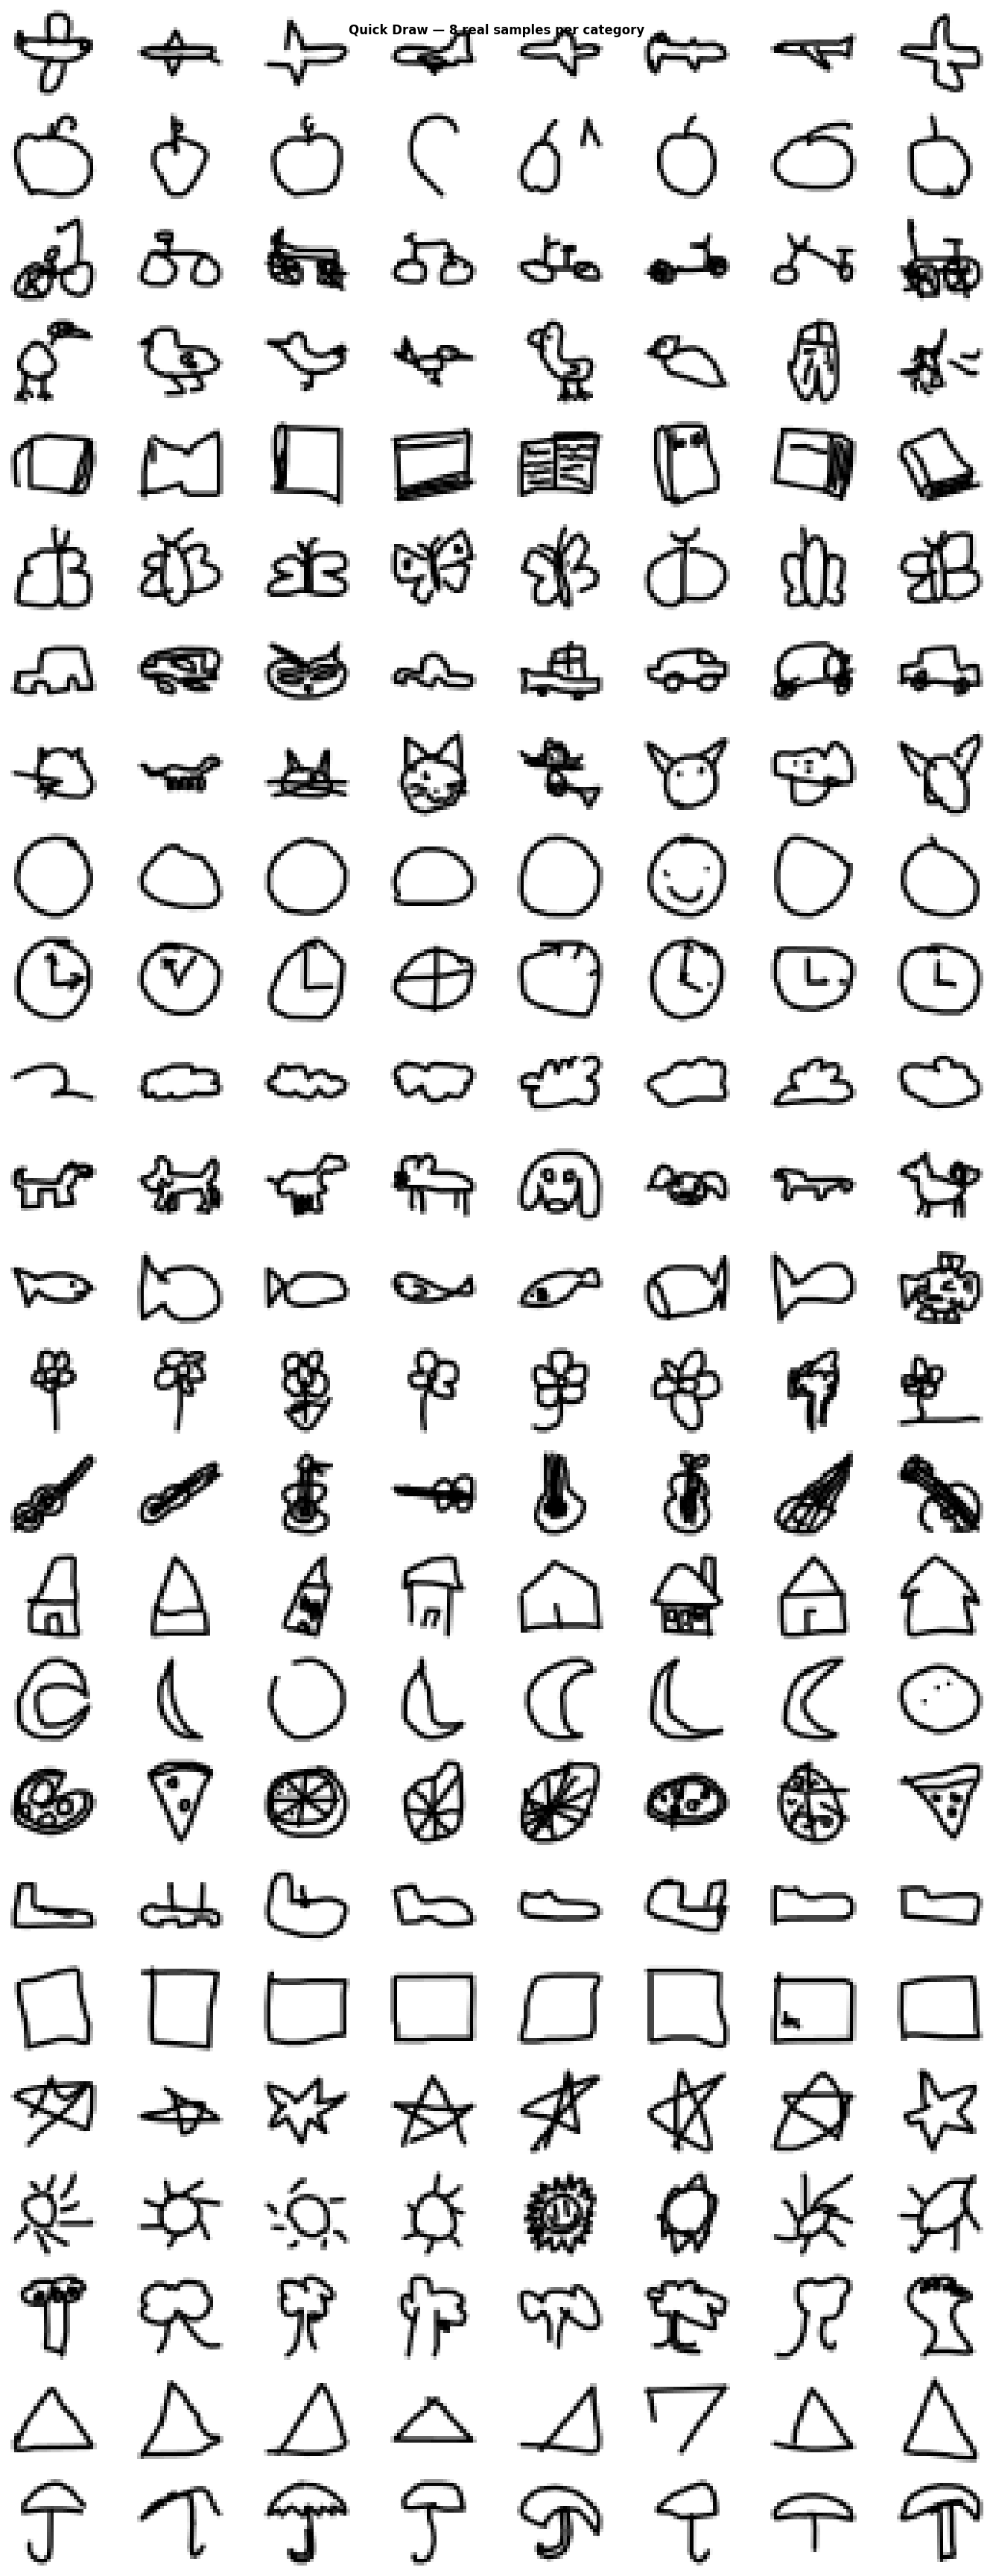

In [22]:
fig, axes = plt.subplots(len(CATEGORIES), 8, figsize=(14, len(CATEGORIES) * 1.4))
fig.suptitle('Quick Draw — 8 real samples per category', fontsize=12, fontweight='bold')

for row, cat in enumerate(CATEGORIES):
    data = np.load(npy[cat], mmap_mode='r')
    idx = np.random.choice(len(data), 8, replace=False)
    for col, i in enumerate(idx):
        ax = axes[row][col]
        ax.imshow(data[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray_r', vmin=0, vmax=255)
        ax.axis('off')
    axes[row][0].set_ylabel(cat, fontsize=8, rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.show()

## 5 · Build the Dataset

Sample `SAMPLES` drawings per category, normalize pixel values, and split into training and validation sets.

Quick Draw bitmaps are stored as `0 = white background, 255 = ink`. They're inverted here to `0 = white, 1 = ink` so pixel values match what the browser sends at inference time.

In [23]:
print(f'Loading {SAMPLES:,} samples × {len(CATEGORIES)} categories...')
print('-' * 48)

X_parts, y_parts = [], []
for cat_idx, cat in enumerate(CATEGORIES):
    raw = np.load(npy[cat])
    idx = np.random.choice(len(raw), SAMPLES, replace=False)
    imgs = raw[idx].reshape(-1, IMG_SIZE, IMG_SIZE).astype(np.float32)
    imgs = 1.0 - imgs / 255.0
    X_parts.append(imgs)
    y_parts.append(np.full(SAMPLES, cat_idx, dtype=np.int32))
    print(f'  {cat:<14} {SAMPLES:,} samples ✓')

X = np.concatenate(X_parts).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.concatenate(y_parts)

perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=VAL_SPLIT, random_state=SEED, stratify=y)

print('-' * 48)
print(f'Total: {len(X):,}  Train: {len(X_train):,}  Val: {len(X_val):,}')
print(f'Shape: {X_train.shape}  dtype: {X_train.dtype}')

Loading 10,000 samples × 25 categories...
------------------------------------------------
  airplane       10,000 samples ✓
  apple          10,000 samples ✓
  bicycle        10,000 samples ✓
  bird           10,000 samples ✓
  book           10,000 samples ✓
  butterfly      10,000 samples ✓
  car            10,000 samples ✓
  cat            10,000 samples ✓
  circle         10,000 samples ✓
  clock          10,000 samples ✓
  cloud          10,000 samples ✓
  dog            10,000 samples ✓
  fish           10,000 samples ✓
  flower         10,000 samples ✓
  guitar         10,000 samples ✓
  house          10,000 samples ✓
  moon           10,000 samples ✓
  pizza          10,000 samples ✓
  shoe           10,000 samples ✓
  square         10,000 samples ✓
  star           10,000 samples ✓
  sun            10,000 samples ✓
  tree           10,000 samples ✓
  triangle       10,000 samples ✓
  umbrella       10,000 samples ✓
------------------------------------------------
Total: 250

## 6 · Data Augmentation

Sketches vary in rotation, scale, position, and stroke thickness depending on how a person draws. A light augmentation pipeline — random rotation, zoom, translation, and contrast — helps the model generalize to those variations instead of memorizing exact pixel layouts. Augmentation is applied only to the training set, inside the `tf.data` pipeline, so it runs on the fly each epoch.

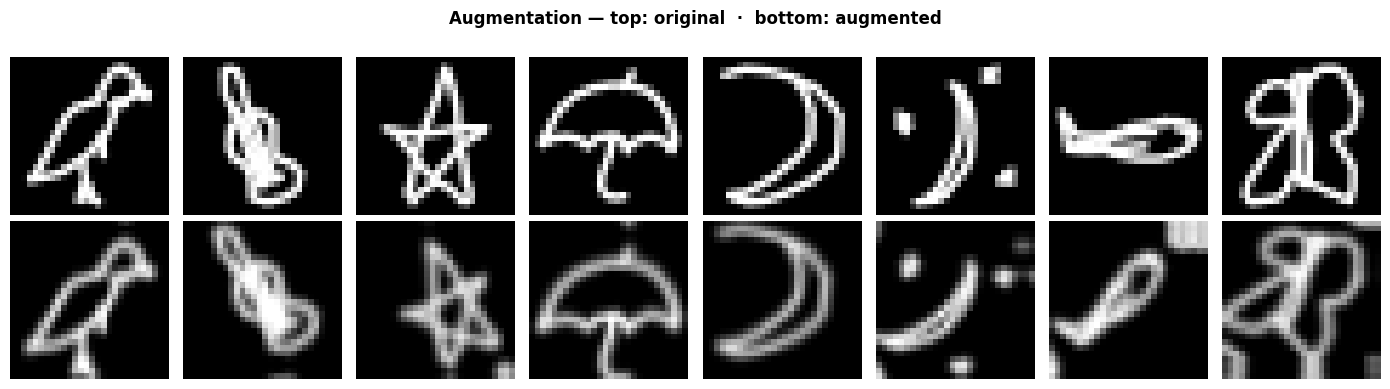

Train batches/epoch: 1661  Val batches: 293


In [24]:
AUTOTUNE = tf.data.AUTOTUNE

augment = keras.Sequential([
    layers.RandomRotation(0.12),           # ±43°
    layers.RandomZoom(0.15),               # ±15%
    layers.RandomTranslation(0.10, 0.10),  # ±10%
    layers.RandomContrast(0.15),           # handles thick/thin strokes
], name='augmentation')

def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(12000, seed=SEED)
        ds = ds.batch(BATCH_SIZE).map(
            lambda x, lbl: (augment(x, training=True), lbl),
            num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val,   training=False)

# Preview a few augmented samples
sample8 = X_train[:8]
aug8 = augment(sample8, training=True).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Augmentation — top: original  ·  bottom: augmented', fontweight='bold')
for col in range(8):
    axes[0][col].imshow(sample8[col].squeeze(), cmap='gray_r', vmin=0, vmax=1)
    axes[0][col].axis('off')
    axes[1][col].imshow(aug8[col].squeeze(), cmap='gray_r', vmin=0, vmax=1)
    axes[1][col].axis('off')
plt.tight_layout()
plt.show()

print(f'Train batches/epoch: {len(train_ds)}  Val batches: {len(val_ds)}')

## 7 · Model Architecture

A compact CNN with three convolutional blocks followed by a dense classification head:

| Block | Layers |
|-------|--------|
| 1 | Conv(32) → BN → ReLU → Conv(32) → BN → ReLU → MaxPool → Dropout(0.25) |
| 2 | Conv(64) → BN → ReLU → Conv(64) → BN → ReLU → MaxPool → Dropout(0.25) |
| 3 | Conv(128) → BN → ReLU → GlobalAveragePooling |
| Head | Dense(512) → BN → ReLU → Dropout(0.5) → Dense(25, softmax) |

Batch normalization stabilizes and speeds up training. Dropout and global average pooling (instead of flattening) help control overfitting given the relatively small 28×28 input.

In [25]:
def build_model():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name='sketch')

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, name='conv1a')(inp)
    x = layers.BatchNormalization(name='bn1a')(x)
    x = layers.Activation('relu', name='act1a')(x)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, name='conv1b')(x)
    x = layers.BatchNormalization(name='bn1b')(x)
    x = layers.Activation('relu', name='act1b')(x)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', use_bias=False, name='conv2a')(x)
    x = layers.BatchNormalization(name='bn2a')(x)
    x = layers.Activation('relu', name='act2a')(x)
    x = layers.Conv2D(64, 3, padding='same', use_bias=False, name='conv2b')(x)
    x = layers.BatchNormalization(name='bn2b')(x)
    x = layers.Activation('relu', name='act2b')(x)
    x = layers.MaxPooling2D(2, name='pool2')(x)
    x = layers.Dropout(0.25, name='drop2')(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', use_bias=False, name='conv3a')(x)
    x = layers.BatchNormalization(name='bn3a')(x)
    x = layers.Activation('relu', name='act3a')(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # Classification head
    x = layers.Dense(512, use_bias=False, name='dense1')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Activation('relu', name='act_head')(x)
    x = layers.Dropout(0.5, name='drop_head')(x)
    out = layers.Dense(len(CATEGORIES), activation='softmax', name='predictions')(x)

    return keras.Model(inp, out, name='nexus_draw_cnn_v2')

model = build_model()
model.summary()
print(f'\nTrainable params: {model.count_params():,}')

Model: "nexus_draw_cnn_v2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sketch (InputLayer)         [(None, 28, 28, 1)]       0         
                                                                 
 conv1a (Conv2D)             (None, 28, 28, 32)        288       
                                                                 
 bn1a (BatchNormalization)   (None, 28, 28, 32)        128       
                                                                 
 act1a (Activation)          (None, 28, 28, 32)        0         
                                                                 
 conv1b (Conv2D)             (None, 28, 28, 32)        9216      
                                                                 
 bn1b (BatchNormalization)   (None, 28, 28, 32)        128       
                                                                 
 act1b (Activation)          (None, 28, 28, 32)  

## 8 · Train the Model

Train with the Adam optimizer and a cosine-decay learning rate schedule, which smoothly anneals the learning rate from `1e-3` toward `0` over the course of training. Two callbacks keep training efficient:

- **ModelCheckpoint** saves the best-performing weights (by validation accuracy) to disk
- **EarlyStopping** halts training if validation accuracy hasn't improved for 10 epochs, then restores the best weights

In [26]:
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=EPOCHS * len(train_ds),
    alpha=1e-6
)

model.compile(
    optimizer=keras.optimizers.Adam(lr_schedule),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=0
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
]

print(f'Training on {len(X_train):,} samples x {len(CATEGORIES)} categories...\n')
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

best_acc = max(history.history['val_accuracy'])
best_loss = min(history.history['val_loss'])
print(f'\n  Best val accuracy : {best_acc*100:.2f} %')
print(f'  Best val loss     : {best_loss:.4f}')

Training on 212,500 samples x 25 categories...

Epoch 1/50


1661/1661 [==============================] - 60s 35ms/step - loss: 1.1616 - accuracy: 0.6617 - val_loss: 1.3211 - val_accuracy: 0.6004
Epoch 2/50
1661/1661 [==============================] - 65s 39ms/step - loss: 0.6429 - accuracy: 0.8153 - val_loss: 0.5852 - val_accuracy: 0.8316
Epoch 3/50
1661/1661 [==============================] - 65s 39ms/step - loss: 0.5519 - accuracy: 0.8422 - val_loss: 0.4391 - val_accuracy: 0.8763
Epoch 4/50
1661/1661 [==============================] - 66s 40ms/step - loss: 0.5057 - accuracy: 0.8559 - val_loss: 0.6186 - val_accuracy: 0.8224
Epoch 5/50
1661/1661 [==============================] - 67s 40ms/step - loss: 0.4741 - accuracy: 0.8642 - val_loss: 0.4914 - val_accuracy: 0.8534
Epoch 6/50
1661/1661 [==============================] - 69s 42ms/step - loss: 0.4547 - accuracy: 0.8708 - val_loss: 0.3851 - val_accuracy: 0.8898
Epoch 7/50
1661/1661 [==============================] - 70s 42ms/step - lo

## 9 · Training Curves

Plot training vs. validation accuracy and loss to check for overfitting or underfitting.

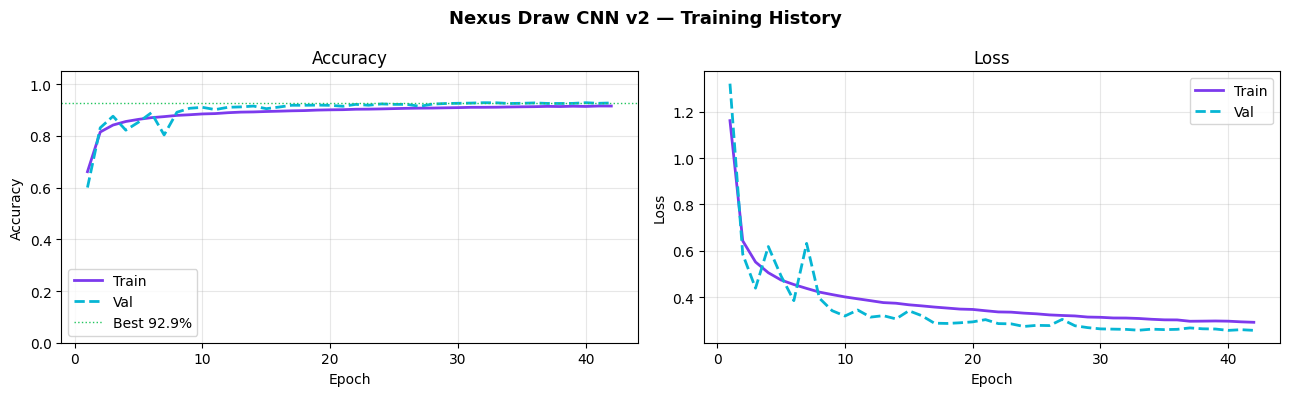

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Nexus Draw CNN v2 — Training History', fontsize=13, fontweight='bold')
ep = range(1, len(history.history['accuracy']) + 1)

ax1.plot(ep, history.history['accuracy'], color='#7c3aed', lw=2, label='Train')
ax1.plot(ep, history.history['val_accuracy'], color='#06b6d4', lw=2, linestyle='--', label='Val')
ax1.axhline(best_acc, color='#22c55e', lw=1, linestyle=':', label=f'Best {best_acc*100:.1f}%')
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1.05))
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ep, history.history['loss'], color='#7c3aed', lw=2, label='Train')
ax2.plot(ep, history.history['val_loss'], color='#06b6d4', lw=2, linestyle='--', label='Val')
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10 · Evaluation

Generate a full classification report (precision, recall, F1 per category) and a normalized confusion matrix to see which categories the model confuses most often.

Classification Report
              precision    recall  f1-score   support

    airplane      0.880     0.922     0.901      1500
       apple      0.975     0.955     0.965      1500
     bicycle      0.945     0.980     0.962      1500
        bird      0.849     0.811     0.829      1500
        book      0.939     0.967     0.953      1500
   butterfly      0.954     0.963     0.959      1500
         car      0.941     0.951     0.946      1500
         cat      0.851     0.859     0.855      1500
      circle      0.859     0.925     0.891      1500
       clock      0.946     0.961     0.954      1500
       cloud      0.973     0.919     0.945      1500
         dog      0.761     0.819     0.789      1500
        fish      0.969     0.923     0.946      1500
      flower      0.963     0.915     0.938      1500
      guitar      0.970     0.963     0.967      1500
       house      0.955     0.975     0.965      1500
        moon      0.905     0.761     0.827      1500
     

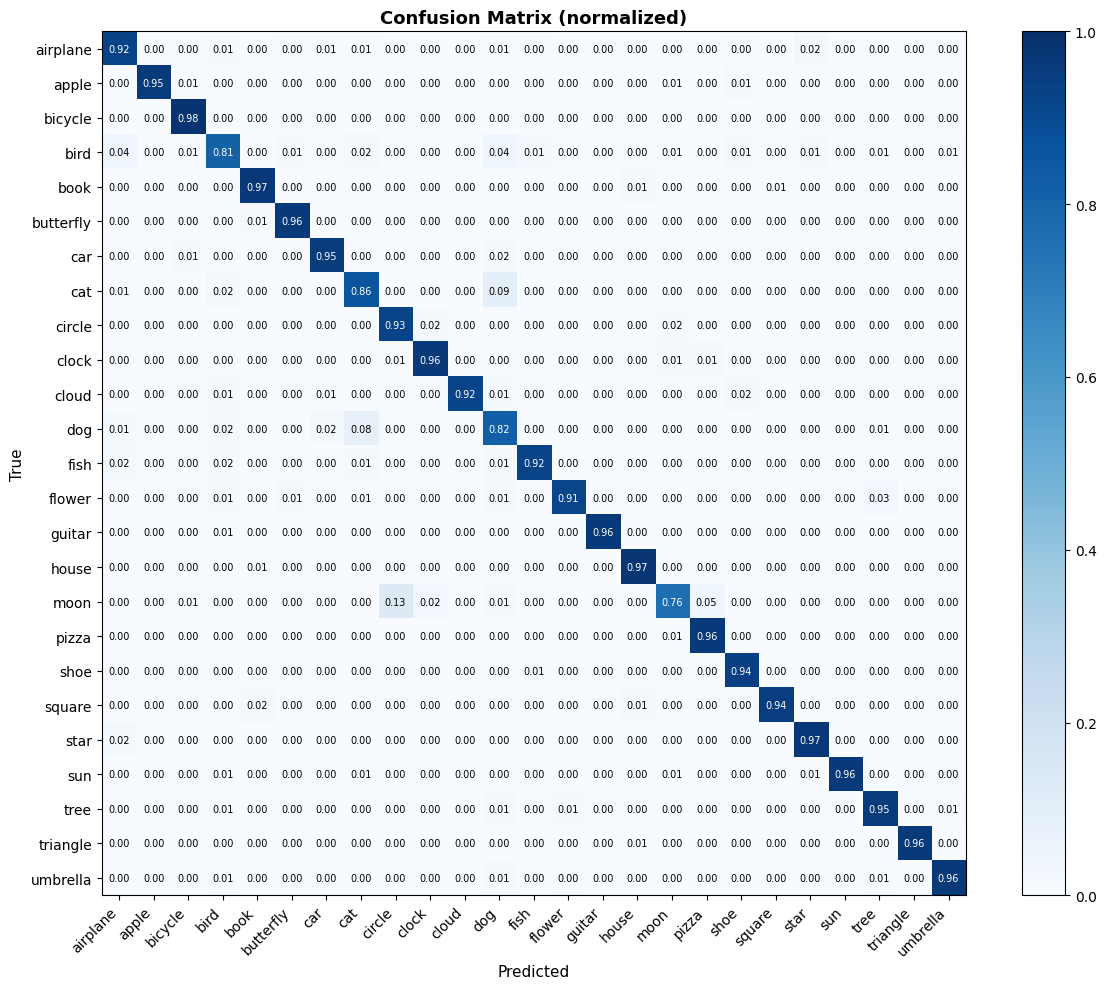

In [28]:
y_probs = model.predict(val_ds, verbose=0)
y_pred = y_probs.argmax(axis=1)

print('=' * 64)
print('Classification Report')
print('=' * 64)
print(classification_report(y_val, y_pred, target_names=CATEGORIES, digits=3))

cm = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.04)
tick = range(len(CATEGORIES))
ax.set_xticks(tick); ax.set_xticklabels(CATEGORIES, rotation=45, ha='right')
ax.set_yticks(tick); ax.set_yticklabels(CATEGORIES)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('Confusion Matrix (normalized)', fontsize=13, fontweight='bold')
for i in range(len(CATEGORIES)):
    for j in range(len(CATEGORIES)):
        c = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center', fontsize=7, color=c)
plt.tight_layout()
plt.show()

## 11 · Sample Predictions

Inspect a few validation predictions per category. Borders are green for correct predictions and red for incorrect ones, with the predicted label shown for mistakes.

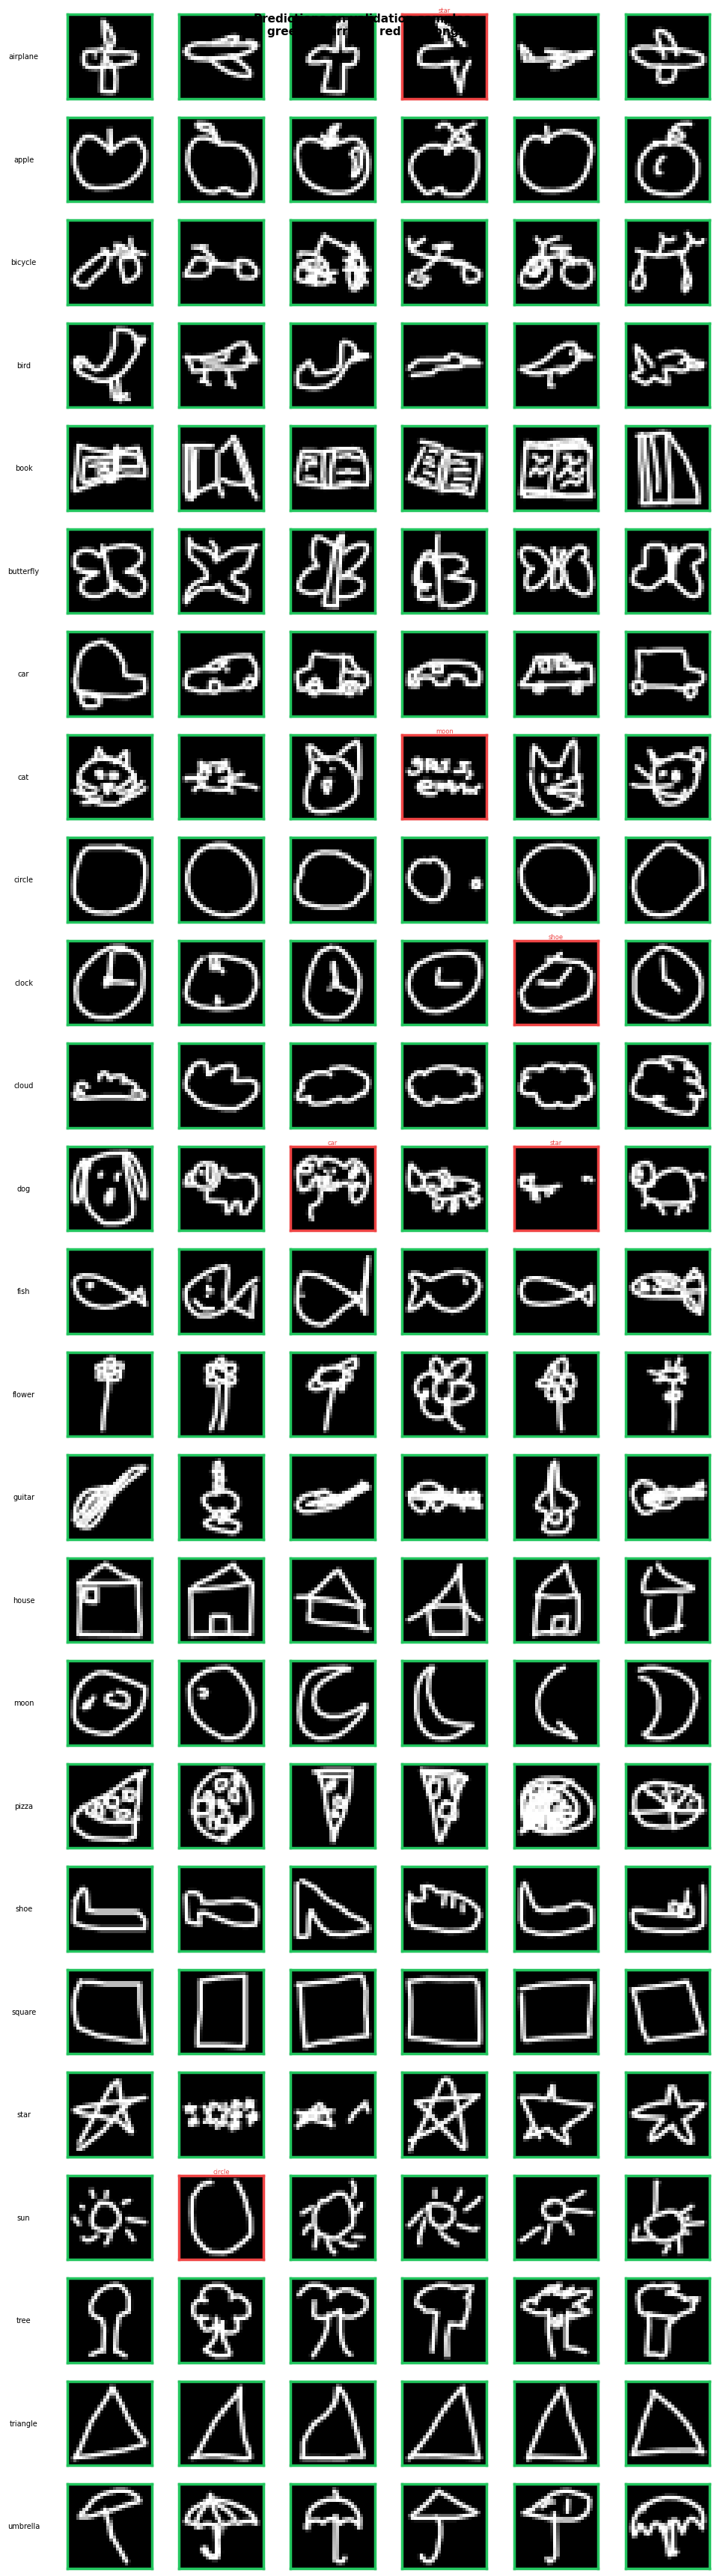

In [29]:
fig, axes = plt.subplots(len(CATEGORIES), 6, figsize=(10, len(CATEGORIES) * 1.4))
fig.suptitle('Predictions on validation samples\ngreen = correct   red = wrong',
             fontsize=11, fontweight='bold')

for row, (cat_idx, cat) in enumerate(zip(range(len(CATEGORIES)), CATEGORIES)):
    idxs = np.where(y_val == cat_idx)[0][:6]
    for col, si in enumerate(idxs):
        ax = axes[row][col]
        pred = y_pred[si]
        color = '#22c55e' if pred == cat_idx else '#ef4444'
        ax.imshow(X_val[si].squeeze(), cmap='gray_r', vmin=0, vmax=1)
        for sp in ax.spines.values():
            sp.set_edgecolor(color)
            sp.set_linewidth(2.5)
        if pred != cat_idx:
            ax.set_title(CATEGORIES[pred], fontsize=6, color=color, pad=2)
        ax.set_xticks([]); ax.set_yticks([])
    for col in range(len(idxs), 6):
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(cat, fontsize=7, rotation=0, labelpad=42, va='center')

plt.tight_layout()
plt.show()

## 12 · Export to TensorFlow.js

Convert the trained Keras model into TensorFlow.js's `layers-model` format — a `model.json` architecture file plus a binary weights file — so it can be loaded in the browser with `tf.loadLayersModel()`. The conversion is done manually here, writing the JSON and weight bytes directly, which avoids depending on the separate `tensorflowjs` Python package for such a simple export.

In [30]:
def manual_tfjs_export(keras_model, output_dir):
    """Write model.json + group1-shard1of1.bin in TF.js layers-model format."""
    os.makedirs(output_dir, exist_ok=True)

    model_config = json.loads(keras_model.to_json())

    weight_specs = []
    weight_bytes = bytearray()
    for w in keras_model.weights:
        arr = w.numpy().astype(np.float32)
        weight_specs.append({
            'name': w.name.split(':')[0],
            'shape': list(arr.shape),
            'dtype': 'float32'
        })
        weight_bytes.extend(arr.tobytes())

    bin_name = 'group1-shard1of1.bin'
    with open(os.path.join(output_dir, bin_name), 'wb') as f:
        f.write(weight_bytes)

    model_json = {
        'format': 'layers-model',
        'generatedBy': f'keras {tf.__version__}',
        'convertedBy': 'nexus-draw-manual-export',
        'modelTopology': model_config,
        'weightsManifest': [{
            'paths': [bin_name],
            'weights': weight_specs
        }]
    }
    with open(os.path.join(output_dir, 'model.json'), 'w') as f:
        json.dump(model_json, f)

print('Exporting to TF.js format...')
manual_tfjs_export(model, OUTPUT_DIR)

files = [f for f in os.listdir(OUTPUT_DIR) if not f.endswith('.txt') and f != '.gitkeep']
total = sum(os.path.getsize(os.path.join(OUTPUT_DIR, f)) for f in files)
print(f'\nFiles in {OUTPUT_DIR}:')
print('-' * 52)
for f in sorted(files):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f:<38}  {sz/1024:>6.1f} KB')
print('-' * 52)
print(f'  Total{" "*33}  {total/1024:>6.1f} KB')
print('\nExport complete ✓')

Exporting to TF.js format...

Files in d:\Kushagra\NexusDraw\nexus-draw\model:
----------------------------------------------------
  group1-shard1of1.bin                     860.2 KB
  model.json                                17.2 KB
----------------------------------------------------
  Total                                    877.4 KB

Export complete ✓


## 13 · Verify the Export

Reload one sample from each category's cached `.npy` file and confirm the trained model still predicts the correct label.

In [31]:
model_json_path = os.path.join(OUTPUT_DIR, 'model.json')
bin_path = os.path.join(OUTPUT_DIR, 'group1-shard1of1.bin')

assert os.path.exists(model_json_path), 'model.json missing!'
assert os.path.exists(bin_path), 'weights .bin missing!'

print('Per-category inference check (sample #500 from each file):')
print('-' * 58)
all_ok = True
for cat_idx, cat in enumerate(CATEGORIES):
    raw = np.load(npy[cat])
    img = 1.0 - raw[500].astype(np.float32) / 255.0
    pred = model.predict(img.reshape(1, IMG_SIZE, IMG_SIZE, 1), verbose=0)[0]
    top1 = CATEGORIES[pred.argmax()]
    conf = pred.max() * 100
    ok = top1 == cat
    bar = chr(9608) * int(conf / 5)
    tick = 'OK' if ok else 'WRONG'
    print(f'  [{tick:5}] {cat:<14} -> {top1:<14} [{bar:<20}] {conf:.0f}%')
    if not ok:
        all_ok = False
print('-' * 58)
print('All categories correct!' if all_ok else 'Some wrong — consider raising SAMPLES')

print(f'\nDone! Model exported to:\n  {OUTPUT_DIR}')

Per-category inference check (sample #500 from each file):
----------------------------------------------------------
  [OK   ] airplane       -> airplane       [█████████████████   ] 90%
  [OK   ] apple          -> apple          [███████████████████ ] 100%
  [OK   ] bicycle        -> bicycle        [███████████████████ ] 100%
  [OK   ] bird           -> bird           [███████████████████ ] 100%
  [OK   ] book           -> book           [████████████████████] 100%
  [OK   ] butterfly      -> butterfly      [███████████████████ ] 100%
  [OK   ] car            -> car            [███████████████████ ] 97%
  [OK   ] cat            -> cat            [███████████████████ ] 99%
  [OK   ] circle         -> circle         [██████████████████  ] 92%
  [OK   ] clock          -> clock          [███████████████████ ] 100%
  [OK   ] cloud          -> cloud          [███████████████████ ] 100%
  [OK   ] dog            -> dog            [███████████████████ ] 99%
  [OK   ] fish           -> fish   